# Chapter 1 Companion — From Probability to Geometry

**Tunneling and Risk Management**  
**Alejandro Reynoso — Cambridge Judge Business School / DEFI Capital Research**

> **Educational purpose.** This notebook uses synthetic data. It demonstrates a modelling framework; it does not provide investment, credit, legal, or regulatory advice.

## The five central ideas

1. **Probability is necessary but structurally incomplete.** A scalar probability summarizes likelihood, but does not reveal how an adverse state becomes reachable.
2. **Risk lives in a state space.** A system is represented by a vector of economically meaningful coordinates—here leverage, liquidity, profitability, refinancing dependence, and control strength.
3. **Distance is model-dependent.** The metric determines which movements are important; covariance-adjusted distance can reveal proximity that raw Euclidean distance conceals.
4. **Risk is dynamic.** Drift, diffusion, persistence, feedback, and jumps move the system across a landscape containing stable, fragile, and adverse regions.
5. **Barriers and pathways determine reachability.** Controls, liquidity buffers, covenants, and intervention capacity can obstruct adverse transitions, while narrow weak paths can preserve transmission even when ordinary analysis suggests protection.

The ten experiments below turn these ideas into a reproducible empirical workflow. Each experiment is deliberately compact, visual, and interpretable.

## Cell 1 — Establish the governed, reproducible environment

This cell imports only standard Colab libraries, fixes the random seed, defines the experiment horizon, and records the configuration. Reproducibility is part of governance: every later result can be traced to these settings.

In [1]:
import json, platform, warnings
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
warnings.filterwarnings('ignore')
SEED, N, TRAIN_SHARE = 758, 1200, 0.70
rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid', palette='deep')
CONFIG = {'seed': SEED, 'observations': N, 'train_share': TRAIN_SHARE,
          'generated_utc': datetime.now(timezone.utc).isoformat()}
print(json.dumps(CONFIG, indent=2))

{
  "seed": 758,
  "observations": 1200,
  "train_share": 0.7,
  "generated_utc": "2026-08-05T15:18:28.632759+00:00"
}


## Cell 2 — Construct a synthetic risk-bearing system

We create a time-ordered panel of synthetic borrowers. The five state coordinates interact nonlinearly, and a latent refinancing shock creates a hidden route to distress. The adverse-event label is generated only after the full structural state has been defined.

In [2]:
t = np.arange(N)
cycle = np.sin(2*np.pi*t/240)
leverage = np.clip(rng.normal(0.50 + 0.08*cycle, 0.13, N), 0.05, 0.95)
liquidity = np.clip(0.78 - 0.55*leverage + rng.normal(0, 0.12, N), 0.02, 0.98)
profitability = np.clip(0.70 - 0.42*leverage + 0.10*cycle + rng.normal(0, 0.12, N), 0.02, 0.98)
refinancing = np.clip(0.18 + 0.58*leverage - 0.22*liquidity + rng.normal(0, 0.12, N), 0.01, 0.99)
controls = np.clip(rng.beta(5, 2, N) - 0.12*(refinancing > 0.75), 0.02, 0.99)
hidden_route = ((refinancing > 0.72) & (liquidity < 0.42)).astype(float)
latent = -4.6 + 3.0*leverage - 2.0*liquidity - 1.3*profitability + 2.1*refinancing - 1.0*controls + 2.6*hidden_route
true_pd = 1/(1 + np.exp(-latent))
default = rng.binomial(1, true_pd)
df = pd.DataFrame({'time': t, 'leverage': leverage, 'liquidity': liquidity,
                   'profitability': profitability, 'refinancing': refinancing,
                   'controls': controls, 'hidden_route': hidden_route,
                   'true_pd': true_pd, 'default': default})
display(df.head())
print(f'Default rate: {df.default.mean():.2%} | Hidden-route prevalence: {df.hidden_route.mean():.2%}')

,time,leverage,liquidity,profitability,refinancing,controls,hidden_route,true_pd,default
0,0,0.542805,0.454792,0.579213,0.416297,0.671338,0.0,0.011760,0
1,1,0.517653,0.175189,0.586622,0.532811,0.844161,0.0,0.020129,0
2,2,0.784361,0.179522,0.351036,0.583213,0.915720,0.0,0.059902,0
3,3,0.727499,0.243870,0.441087,0.539404,0.926049,0.0,0.036546,0
4,4,0.556012,0.353165,0.546222,0.193024,0.581782,0.0,0.010721,0


Default rate: 1.42% | Hidden-route prevalence: 0.58%


## Cell 3 — Show what a scalar probability reveals and conceals

A conventional probability score is useful for ranking risk. We group observations into probability bands and then show that borrowers with similar probabilities may occupy very different structural configurations. This is the chapter's point of departure.

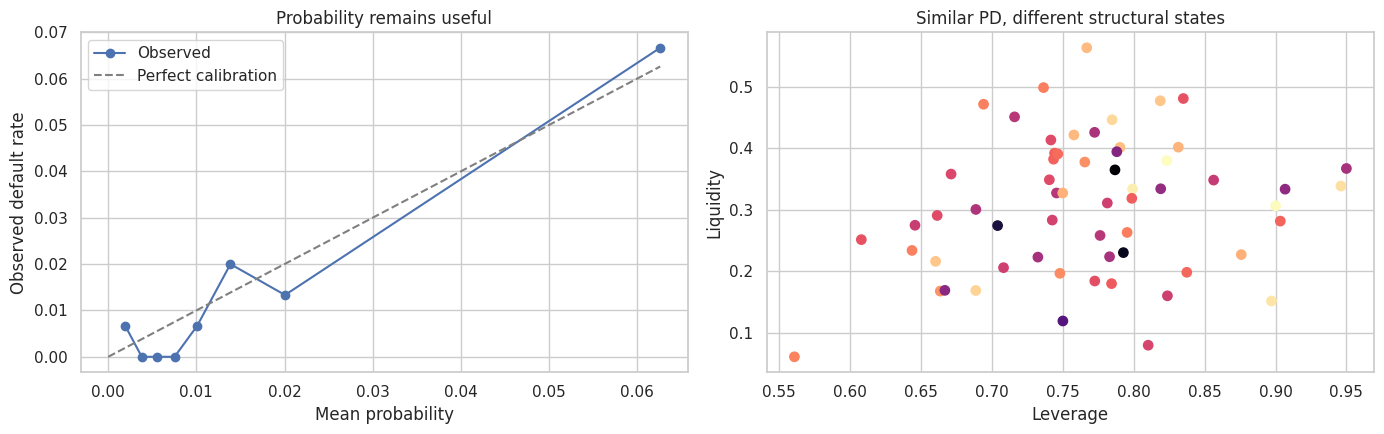

,mean_pd,observed_default,leverage,refinancing,liquidity,route_share
pd_band,,,,,,
"(-0.00045200000000000004, 0.00292]",0.002,0.007,0.282,0.148,0.678,0.000
"(0.00292, 0.00465]",0.004,0.000,0.383,0.247,0.602,0.000
"(0.00465, 0.00653]",0.006,0.000,0.443,0.288,0.569,0.000
"(0.00653, 0.00862]",0.008,0.000,0.472,0.337,0.524,0.000
"(0.00862, 0.0117]",0.010,0.007,0.518,0.368,0.489,0.000
"(0.0117, 0.0162]",0.014,0.020,0.554,0.433,0.457,0.000
"(0.0162, 0.0254]",0.020,0.013,0.604,0.458,0.418,0.000
"(0.0254, 0.661]",0.063,0.067,0.712,0.564,0.341,0.047


In [3]:
df['pd_band'] = pd.qcut(df.true_pd, 8, duplicates='drop')
band = df.groupby('pd_band', observed=True).agg(mean_pd=('true_pd','mean'), observed_default=('default','mean'),
                                                  leverage=('leverage','mean'), refinancing=('refinancing','mean'),
                                                  liquidity=('liquidity','mean'), route_share=('hidden_route','mean'))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(band.mean_pd, band.observed_default, 'o-', label='Observed')
ax[0].plot([0, band.mean_pd.max()], [0, band.mean_pd.max()], '--', color='gray', label='Perfect calibration')
ax[0].set(xlabel='Mean probability', ylabel='Observed default rate', title='Probability remains useful')
ax[0].legend()
near = df.iloc[(df.true_pd-0.12).abs().argsort()[:60]]
ax[1].scatter(near.leverage, near.liquidity, c=near.refinancing, s=45, cmap='magma')
ax[1].set(xlabel='Leverage', ylabel='Liquidity', title='Similar PD, different structural states')
plt.tight_layout(); plt.show()
display(band.round(3))

## Cell 4 — Map the state space and its risk regions

We project the multidimensional system onto leverage and liquidity—two interpretable coordinates—and classify observations as stable, fragile, or adverse. The plot replaces a binary safe/fail view with a continuum of configurations.

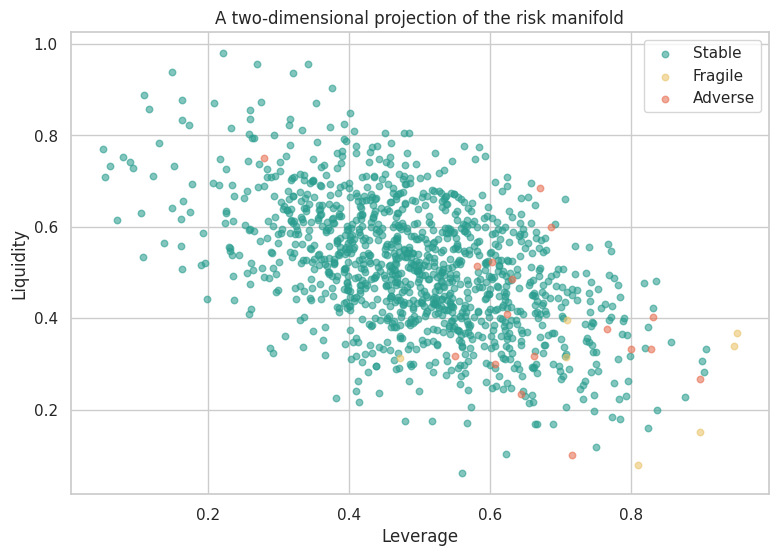

default,No default,Default
region,,
Adverse,0.0,1.0
Fragile,1.0,0.0
Stable,1.0,0.0


In [4]:
df['region'] = np.select([df.default.eq(1), (df.true_pd > 0.10) | (df.hidden_route == 1)],
                         ['Adverse', 'Fragile'], default='Stable')
colors = {'Stable':'#2a9d8f', 'Fragile':'#e9c46a', 'Adverse':'#e76f51'}
fig, ax = plt.subplots(figsize=(9, 6))
for region in ['Stable','Fragile','Adverse']:
    q = df[df.region == region]
    ax.scatter(q.leverage, q.liquidity, s=22, alpha=.58, label=region, c=colors[region])
ax.set(xlabel='Leverage', ylabel='Liquidity', title='A two-dimensional projection of the risk manifold')
ax.legend(); plt.show()
display(pd.crosstab(df.region, df.default, normalize='index').rename(columns={0:'No default',1:'Default'}).round(3))

## Cell 5 — Compare Euclidean and covariance-adjusted risk distance

Raw distance weights every coordinate equally and ignores dependence. Mahalanobis distance uses the inverse covariance matrix as a metric tensor. We measure each observation's distance from the adverse-state centroid and compare the resulting rankings.

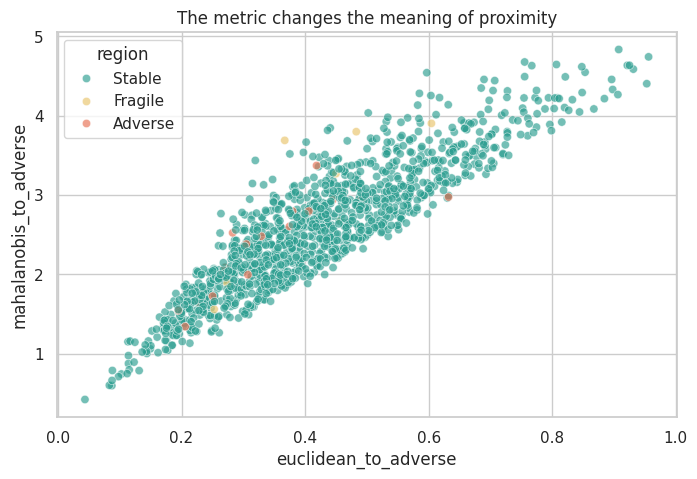

Rank correlation: 0.892


In [5]:
features = ['leverage','liquidity','profitability','refinancing','controls']
X = df[features].to_numpy()
adverse_center = df.loc[df.default.eq(1), features].mean().to_numpy()
df['euclidean_to_adverse'] = np.linalg.norm(X-adverse_center, axis=1)
VI = np.linalg.pinv(np.cov(X, rowvar=False))
df['mahalanobis_to_adverse'] = [mahalanobis(x, adverse_center, VI) for x in X]
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='euclidean_to_adverse', y='mahalanobis_to_adverse', hue='region',
                palette=colors, alpha=.65, ax=ax)
ax.set_title('The metric changes the meaning of proximity'); plt.show()
print('Rank correlation:', round(df.euclidean_to_adverse.corr(df.mahalanobis_to_adverse, method='spearman'), 3))

## Cell 6 — Build a potential landscape

A potential function summarizes relative stability and directional forces. We construct an interpretable landscape over leverage and liquidity. Valleys represent comparatively stable configurations; slopes and ridges represent forces and resistance.

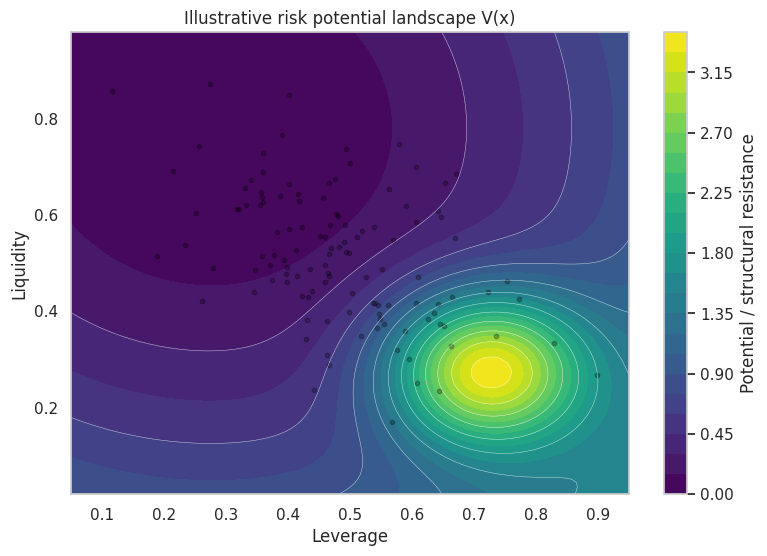

In [6]:
lv = np.linspace(.05, .95, 120); lq = np.linspace(.02, .98, 120)
L, Q = np.meshgrid(lv, lq)
V = 1.8*(L-.28)**2 + 1.4*(Q-.78)**2 + 2.7*np.exp(-((L-.72)**2+(Q-.28)**2)/.025)
fig, ax = plt.subplots(figsize=(9, 6))
cont = ax.contourf(L, Q, V, levels=30, cmap='viridis')
ax.contour(L, Q, V, levels=12, colors='white', linewidths=.35, alpha=.7)
ax.scatter(df.leverage.sample(120, random_state=SEED), df.liquidity.sample(120, random_state=SEED),
           s=10, c='black', alpha=.25)
ax.set(xlabel='Leverage', ylabel='Liquidity', title='Illustrative risk potential landscape V(x)')
plt.colorbar(cont, ax=ax, label='Potential / structural resistance'); plt.show()

## Cell 7 — Simulate drift, diffusion, and a discontinuous jump

A state space becomes a risk model only after a law of motion is specified. This simulation separates deterministic deterioration, stochastic variation, and a refinancing jump. It visualizes why the current position alone cannot determine reachability.

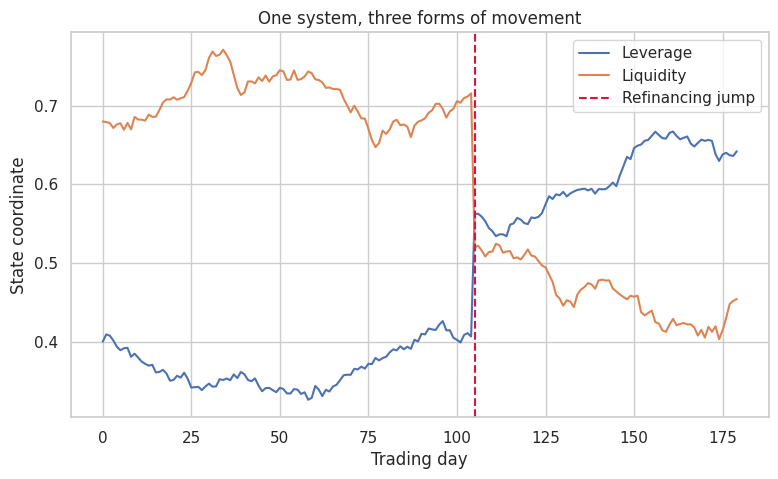

In [7]:
steps, dt = 180, 1/252
path = np.zeros((steps,2)); path[0] = [.40,.68]
for i in range(1, steps):
    drift = np.array([.16, -.20])*dt
    diffusion = np.array([.10,.12])*np.sqrt(dt)*rng.normal(size=2)
    jump = np.array([.16,-.20]) if i == 105 else 0
    path[i] = np.clip(path[i-1] + drift + diffusion + jump, .01, .99)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(path[:,0], label='Leverage'); ax.plot(path[:,1], label='Liquidity')
ax.axvline(105, color='crimson', linestyle='--', label='Refinancing jump')
ax.set(xlabel='Trading day', ylabel='State coordinate', title='One system, three forms of movement')
ax.legend(); plt.show()

## Cell 8 — Represent barriers and competing transition pathways

We encode three routes from the current state to distress. Edge weights represent integrated resistance: control strength, liquidity capacity, timing, and dependency. A shortest-path calculation identifies the route requiring the least action, not simply the route containing the weakest single control.

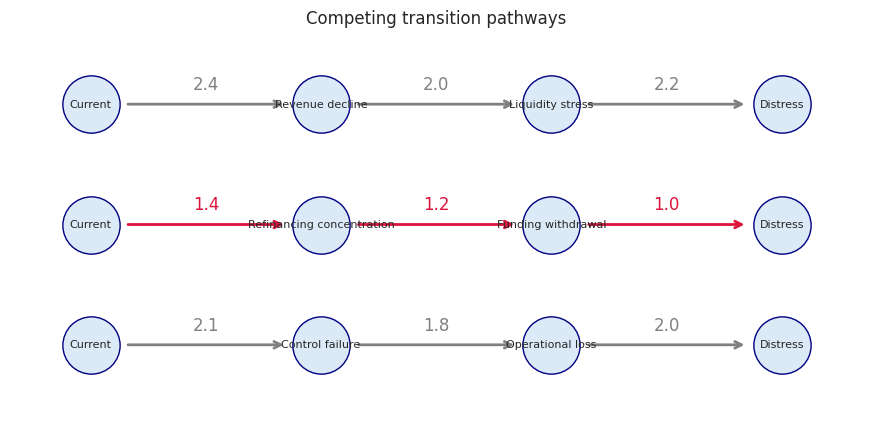

Minimum-action route: Current → Refinancing concentration → Funding withdrawal → Distress | Integrated resistance: 3.6


In [8]:
edges = [('Current','Revenue decline',2.4),('Revenue decline','Liquidity stress',2.0),
         ('Liquidity stress','Distress',2.2),('Current','Refinancing concentration',1.4),
         ('Refinancing concentration','Funding withdrawal',1.2),('Funding withdrawal','Distress',1.0),
         ('Current','Control failure',2.1),('Control failure','Operational loss',1.8),
         ('Operational loss','Distress',2.0)]
paths = [['Current','Revenue decline','Liquidity stress','Distress'],
         ['Current','Refinancing concentration','Funding withdrawal','Distress'],
         ['Current','Control failure','Operational loss','Distress']]
weight = {(u,v):w for u,v,w in edges}
actions = [sum(weight[(u,v)] for u,v in zip(p[:-1],p[1:])) for p in paths]
route, action = paths[int(np.argmin(actions))], min(actions)
fig, ax = plt.subplots(figsize=(11,5))
for row,p in enumerate(paths):
    y = 2-row
    for j,node in enumerate(p):
        ax.scatter(j,y,s=1700,c='#dceaf7',edgecolor='navy',zorder=3)
        ax.text(j,y,node,ha='center',va='center',fontsize=8,zorder=4)
        if j < len(p)-1:
            c = 'crimson' if p == route else 'gray'
            ax.annotate('',xy=(j+1-.15,y),xytext=(j+.15,y),arrowprops=dict(arrowstyle='->',color=c,lw=2))
            ax.text(j+.5,y+.12,f'{weight[(p[j],p[j+1])]:.1f}',ha='center',color=c)
ax.set_xlim(-.35,3.35); ax.set_ylim(-.6,2.6); ax.axis('off'); ax.set_title('Competing transition pathways'); plt.show()
print('Minimum-action route:', ' → '.join(route), '| Integrated resistance:', round(action,2))

## Cell 9 — Visualize tunneling-inspired barrier permeability

The tunneling analogy focuses on integrated under-barrier difficulty. Using a transparent WKB-inspired expression, we vary barrier height and width and visualize transmission. The exercise is conceptual: parameters require independent empirical calibration before operational use.

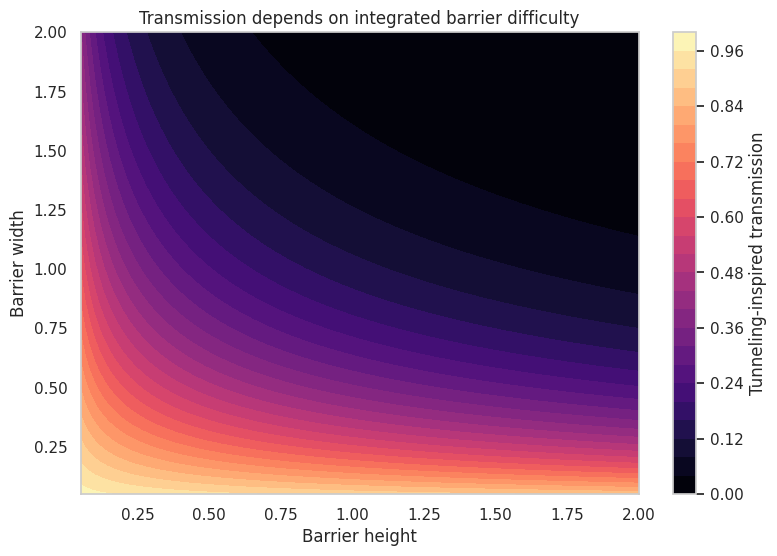

height=1.50, width=0.25 → transmission=0.542
height=0.25, width=1.50 → transmission=0.223
height=0.75, width=0.75 → transmission=0.273


In [9]:
height = np.linspace(.05, 2.0, 120); width = np.linspace(.05, 2.0, 120)
H, W = np.meshgrid(height, width)
effective_resistance = 2*W*np.sqrt(H)
transmission = np.exp(-effective_resistance)
fig, ax = plt.subplots(figsize=(9,6))
hm = ax.contourf(H,W,transmission,levels=30,cmap='magma')
ax.set(xlabel='Barrier height',ylabel='Barrier width',
       title='Transmission depends on integrated barrier difficulty')
plt.colorbar(hm,ax=ax,label='Tunneling-inspired transmission'); plt.show()
for h,w in [(1.5,.25),(.25,1.5),(.75,.75)]:
    print(f'height={h:.2f}, width={w:.2f} → transmission={np.exp(-2*w*np.sqrt(h)):.3f}')

## Cell 10 — Test whether geometry adds empirical value

The final cell performs a locked, time-ordered holdout comparison. The benchmark uses conventional balance-sheet coordinates. The structural model adds distance, pathway, and barrier features. We report AUC and Brier score, preserve a negative result if it occurs, and generate a compact audit manifest.

In [10]:
df['barrier_strength'] = .45*df.liquidity + .35*df.controls + .20*df.profitability
df['path_action'] = 1.6*df.barrier_strength + .8*(1-df.refinancing)
df['permeability'] = np.exp(-2*np.maximum(df.path_action, .01)*np.sqrt(np.maximum(df.leverage, .01)))
cut = int(N*TRAIN_SHARE); train, test = df.iloc[:cut], df.iloc[cut:]
base_cols = ['leverage','liquidity','profitability','refinancing','controls']
geo_cols = base_cols + ['mahalanobis_to_adverse','barrier_strength','path_action','permeability','hidden_route']
rows = []
for name, cols in [('Probability benchmark',base_cols),('Geometry-augmented',geo_cols)]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))
    model.fit(train[cols], train.default); pred = model.predict_proba(test[cols])[:,1]
    rows.append({'model':name,'AUC':roc_auc_score(test.default,pred),
                 'Brier':brier_score_loss(test.default,pred)})
results = pd.DataFrame(rows).set_index('model')
display(results.round(4))
winner = results.AUC.idxmax()
AUDIT = {'chapter':1,'title':'From Probability to Geometry','config':CONFIG,
         'holdout_start_index':cut,'benchmark':results.round(6).to_dict('index'),
         'auc_winner':winner,'limitations':['Synthetic data','Illustrative potential and barrier mapping',
         'No causal claim','External and regime validation required']}
with open('chapter01_run_manifest.json','w') as f: json.dump(AUDIT,f,indent=2)
print(f'AUC winner: {winner}. A negative result would be retained, not suppressed.')
print('Saved: chapter01_run_manifest.json')

,AUC,Brier
model,,
Probability benchmark,0.7060,0.0209
Geometry-augmented,0.7227,0.0221


AUC winner: Geometry-augmented. A negative result would be retained, not suppressed.
Saved: chapter01_run_manifest.json


## Conclusion

This notebook has translated Chapter 1's conceptual movement—from probability to geometry—into an executable research sequence. The starting point was deliberately conventional: a probability of default remains indispensable because it supports ranking, pricing, provisioning, capital allocation, and comparison. Yet the probability bands demonstrated the central limitation of compression. Observations with similar predicted risk can occupy materially different configurations of leverage, liquidity, profitability, refinancing dependence, and control strength. A single number does not identify the route by which failure becomes reachable.

The geometric representation restored that missing structure. The state space located each system within a continuum of stable, fragile, and adverse configurations. The comparison between Euclidean and Mahalanobis distance showed that proximity is not self-defining: it depends on a metric that reflects scale, dependence, and economic interpretation. The potential landscape then supplied a representation of stability, slopes, ridges, and barriers, while the simulated trajectory demonstrated that location must be combined with a law of motion containing drift, diffusion, persistence, and jumps.

The pathway graph added an operational insight. Risk management should search for the minimum integrated resistance connecting the current state to distress, rather than inspect controls one at a time. The tunneling-inspired surface sharpened this idea by showing that transmission depends jointly on barrier height and width. A high but narrow barrier may be more permeable than intuition based on height alone suggests. In financial applications, however, this remains a modelling analogy—not evidence of literal quantum behavior.

Finally, the locked holdout comparison imposed empirical discipline. Geometry earns a place only if its features improve prediction, calibration, explanation, intervention, or early warning beyond strong conventional benchmarks. Negative results must remain visible. The practical conclusion is therefore precise: probability should not be abandoned; it should be grounded in an explicit account of state, distance, dynamics, barriers, pathways, and reachability. That richer account is the foundation on which the remaining chapters build.